# ARC-AGI-3 Random Agent (Local Offline)

Original `arc3-sample-submission-random-agent.ipynb`를 로컬에서 실행할 수 있도록 수정한 버전.
- **커널**: `ARC-AGI-3 (Python 3.12)` 선택 필요
- **모드**: OFFLINE (로컬 환경 파일 사용, API 불필요)

In [1]:
import sys, os

# ARC-AGI-3-Agents 프로젝트 경로를 sys.path에 추가
AGENTS_DIR = os.path.abspath("code/ARC-AGI-3-Agents")
if AGENTS_DIR not in sys.path:
    sys.path.insert(0, AGENTS_DIR)

# 환경 파일 경로 (25개 공개 게임)
ENVIRONMENTS_DIR = os.path.abspath("code/environment_files")

print(f"Agents dir: {AGENTS_DIR}")
print(f"Environments dir: {ENVIRONMENTS_DIR}")
print(f"Games available: {sorted(os.listdir(ENVIRONMENTS_DIR))}")

Agents dir: /Users/sundong/Documents/arc-agi-3/code/ARC-AGI-3-Agents
Environments dir: /Users/sundong/Documents/arc-agi-3/code/environment_files
Games available: ['ar25', 'bp35', 'cd82', 'cn04', 'dc22', 'ft09', 'g50t', 'ka59', 'lf52', 'lp85', 'ls20', 'm0r0', 'r11l', 're86', 's5i5', 'sb26', 'sc25', 'sk48', 'sp80', 'su15', 'tn36', 'tr87', 'tu93', 'vc33', 'wa30']


In [2]:
import random
import time
from typing import Any

from arcengine import FrameData, GameAction, GameState
from agents.agent import Agent


class MyAgent(Agent):
    """Random agent - picks a random action each step."""

    MAX_ACTIONS = float('inf')

    def __init__(self, *args: Any, **kwargs: Any) -> None:
        super().__init__(*args, **kwargs)
        seed = int(time.time() * 1000000) + hash(self.game_id) % 1000000
        random.seed(seed)

    def is_done(self, frames: list[FrameData], latest_frame: FrameData) -> bool:
        return latest_frame.state is GameState.WIN

    def choose_action(self, frames: list[FrameData], latest_frame: FrameData) -> GameAction:
        if latest_frame.state in [GameState.NOT_PLAYED, GameState.GAME_OVER]:
            action = GameAction.RESET
        else:
            action = random.choice([a for a in GameAction if a is not GameAction.RESET])

        if action.is_simple():
            action.reasoning = f"RNG told me to pick {action.value}"
        elif action.is_complex():
            action.set_data({
                "x": random.randint(0, 63),
                "y": random.randint(0, 63),
            })
            action.reasoning = {
                "desired_action": f"{action.value}",
                "my_reason": "RNG said so!",
            }
        return action

print("MyAgent defined!")

MyAgent defined!


/Users/sundong/Documents/arc-agi-3/code/ARC-AGI-3-Agents/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from arc_agi import Arcade, OperationMode
from arcengine import GameAction, GameState
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

os.environ['ENVIRONMENTS_DIR'] = os.path.join(AGENTS_DIR, '..', 'environment_files')

# ARC-AGI color map (0-15)
ARC_COLORS = [
    '#000000', '#0074D9', '#FF4136', '#2ECC40', '#FFDC00',
    '#AAAAAA', '#F012BE', '#FF851B', '#7FDBFF', '#B10DC9',
    '#3D9970', '#001f3f', '#85144b', '#39CCCC', '#01FF70', '#FFFFFF'
]
arc_cmap = mcolors.ListedColormap(ARC_COLORS)

def show_frame(frame, title=""):
    """Display a single ARC grid frame."""
    grid = np.array(frame)
    fig, ax = plt.subplots(1, 1, figsize=(6, 6))
    ax.imshow(grid, cmap=arc_cmap, vmin=0, vmax=15, interpolation='nearest')
    ax.set_title(title)
    ax.grid(True, linewidth=0.5, alpha=0.3)
    plt.tight_layout()
    plt.show()

print("Arcade + visualization ready!")

Arcade + visualization ready!


## Run: Random Agent on a single game

`ls20` 게임에서 random agent를 100 step 돌려봅니다. 초기 프레임과 최종 프레임을 시각화합니다.

2026-03-29 17:45:20 | INFO | Created new scorecard: ca6bcbbe-d01a-43fa-84ca-1e081fead1c4
2026-03-29 17:45:20 | INFO | Found latest version of ls20: ls20-9607627b (downloaded: 2026-03-23 01:12:50.993027+00:00)
2026-03-29 17:45:20 | INFO | Successfully loaded game class Ls20 from /Users/sundong/Documents/arc-agi-3/code/ARC-AGI-3-Agents/../environment_files/ls20/9607627b/ls20.py
Game: ls20
State: GameState.NOT_FINISHED
Available actions: [1, 2, 3, 4]
Grid shape: 64x64


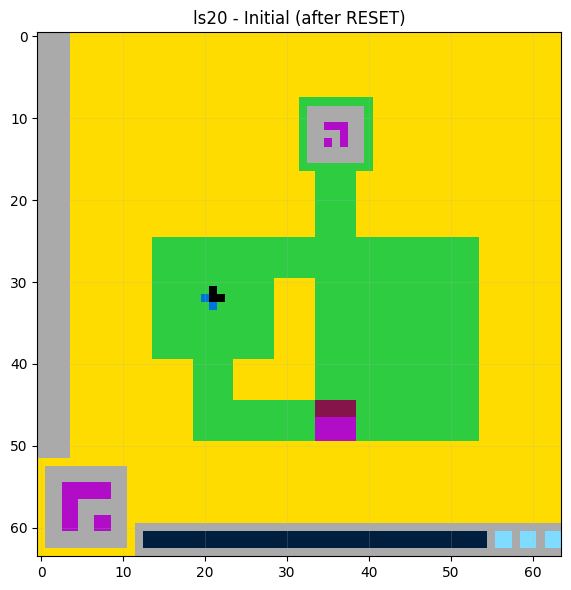

In [4]:
GAME_ID = "ls20"
MAX_STEPS = 100

arc = Arcade(operation_mode=OperationMode.OFFLINE)
env = arc.make(GAME_ID)

# Reset
obs = env.reset()
initial_frame = obs.frame[-1]  # last element = current grid
print(f"Game: {GAME_ID}")
print(f"State: {obs.state}")
print(f"Available actions: {obs.available_actions}")
print(f"Grid shape: {len(obs.frame[-1])}x{len(obs.frame[-1][0])}")

show_frame(initial_frame, f"{GAME_ID} - Initial (after RESET)")


Completed 100 steps
Final state: NOT_FINISHED, Levels completed: 0

Action distribution:
  ACTION2: 29
  ACTION1: 27
  ACTION3: 24
  ACTION4: 20


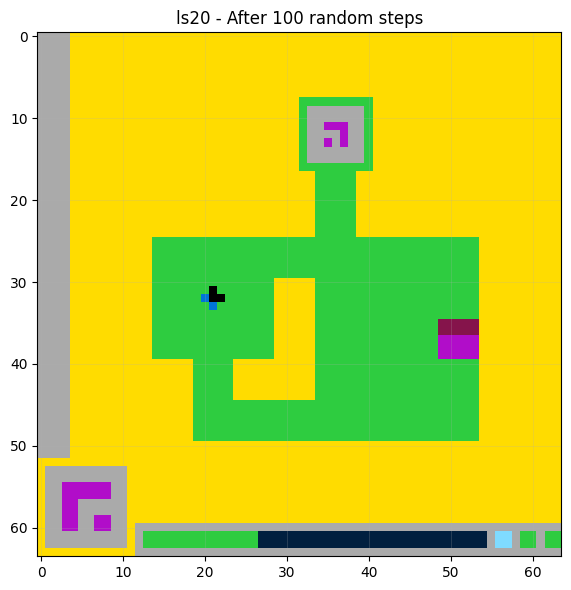

In [5]:
# Run random actions
import random

random.seed(42)
action_map = {a.value: a for a in GameAction}
history = []

for step in range(MAX_STEPS):
    if obs.state == GameState.WIN:
        print(f"WIN at step {step}! Levels completed: {obs.levels_completed}")
        break
    if obs.state == GameState.GAME_OVER:
        print(f"GAME_OVER at step {step}, resetting...")
        obs = env.reset()
        history.append(("RESET", obs.state.name, obs.levels_completed))
        continue

    # Pick random available action
    avail = [action_map[a] for a in obs.available_actions if a != GameAction.RESET.value]
    if not avail:
        avail = [GameAction.RESET]
    action = random.choice(avail)

    # For complex actions (ACTION6), add coordinates
    if action.is_complex():
        action.set_data({"x": random.randint(0, 63), "y": random.randint(0, 63)})

    obs = env.step(action)
    history.append((action.name, obs.state.name, obs.levels_completed))

print(f"\nCompleted {len(history)} steps")
print(f"Final state: {obs.state.name}, Levels completed: {obs.levels_completed}")
print(f"\nAction distribution:")
from collections import Counter
action_counts = Counter(h[0] for h in history)
for action, count in action_counts.most_common():
    print(f"  {action}: {count}")

# Show final frame
show_frame(obs.frame[-1], f"{GAME_ID} - After {len(history)} random steps")

## Bonus: Run on all 25 games (via Swarm)

Swarm을 사용해서 전체 게임에 random agent를 돌려볼 수도 있습니다. (시간이 좀 걸립니다)

In [8]:
# Uncomment to run all 25 games via CLI (takes a while with random agent)
!cd {AGENTS_DIR} && uv run main.py --agent=random --game=ls20

https://three.arcprize.org/api/games
2026-03-29 17:46:06,435 | INFO | Game list: ['ls20-9607627b']
***** MAKING SCORECARD
2026-03-29 17:46:06 | INFO | Created new scorecard: fb746605-db13-49d9-a604-e34ac54fb899
2026-03-29 17:46:06,438 | INFO | Created new scorecard: fb746605-db13-49d9-a604-e34ac54fb899
***** MAKING ALL AGENTS with card id: fb746605-db13-49d9-a604-e34ac54fb899
2026-03-29 17:46:06 | INFO | Successfully loaded game class Ls20 from environment_files/ls20/9607627b/ls20.py
2026-03-29 17:46:06,458 | INFO | Successfully loaded game class Ls20 from environment_files/ls20/9607627b/ls20.py
2026-03-29 17:46:06,461 | INFO | created new recording for ls20-9607627b.random.80 into recordings/ls20-9607627b.random.80.28aa5062-197e-4f67-b4fd-94254bb585f0.recording.jsonl
2026-03-29 17:46:06,463 | INFO | ls20-9607627b - ACTION2: count 0, levels completed 0, avg fps 0.0)
2026-03-29 17:46:06,465 | INFO | ls20-9607627b - ACTION3: count 1, levels completed 0, avg fps 10.0)
2026-03-29 17:46:06,